In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the file
url = "https://raw.githubusercontent.com/mohamedbouzzit01/powerlifting-market-and-growth-analysis/refs/heads/main/Original%20Data.csv"
df = pd.read_csv(url)

In [3]:
# checking the file
df.head()

,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName
0,0,365strong/1601,365Strong,10/29/2016,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...
1,1,365strong/1602,365Strong,11/19/2016,USA,MO,Ozark,Thanksgiving Powerlifting Classic
2,2,365strong/1603,365Strong,7/9/2016,USA,NC,Charlotte,Charlotte Europa Games
3,3,365strong/1604,365Strong,6/11/2016,USA,SC,Rock Hill,Carolina Cup Push Pull Challenge
4,4,365strong/1605,365Strong,4/10/2016,USA,SC,Rock Hill,Eastern USA Challenge


# Start Data cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8482 entries, 0 to 8481
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   MeetID       8482 non-null   int64 
 1   MeetPath     8482 non-null   object
 2   Federation   8482 non-null   object
 3   Date         8482 non-null   object
 4   MeetCountry  8482 non-null   object
 5   MeetState    5496 non-null   object
 6   MeetTown     6973 non-null   object
 7   MeetName     8482 non-null   object
dtypes: int64(1), object(7)
memory usage: 530.3+ KB


In [5]:
df["MeetID"].nunique()

8482

In [6]:
df["MeetID"].duplicated().sum()

np.int64(0)

In [7]:
df["MeetPath"].nunique()

8482

In [8]:
df["Federation"].nunique()

60

In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [10]:
df["Date"].isna().sum()

np.int64(0)

In [11]:
df["Federation"].value_counts()


Federation
NSF               2517
USAPL              976
CPU                969
USPA               864
THSPA              670
PA                 493
SPF                480
RPS                334
NZPF               179
NASA               103
USPF                91
IPA                 88
UPA                 84
IPF                 78
CPF                 58
APF                 53
NIPF                36
APA                 33
BP                  31
EPF                 26
IPL                 21
IrishPF             20
WRPF                20
RAW                 18
GPC-AUS             17
CommonwealthPF      16
XPC                 15
365Strong           14
CPL                 13
SCT                 12
WPC                 12
NAPF                11
ProRaw              11
BB                  11
EPA                 11
GPC                 10
HERC                10
RUPC                 9
OceaniaPF            8
FPO                  8
CAPO                 7
AAU                  7
FFForce              6


In [12]:
df["MeetCountry"].value_counts()

MeetCountry
USA                  3894
Norway               2521
Canada               1066
Australia             532
New Zealand           195
Russia                 43
N.Ireland              36
UK                     34
Ireland                21
England                16
Finland                16
Czechia                12
South Africa            8
Spain                   8
Serbia                  7
France                  6
Italy                   6
India                   5
Sweden                  4
Estonia                 4
Ukraine                 4
Scotland                4
Brazil                  3
US Virgin Islands       3
Poland                  3
Belarus                 3
Germany                 3
Colombia                3
Greece                  2
Kazakhstan              2
Luxembourg              2
Puerto Rico             2
Denmark                 2
Iceland                 1
Netherlands             1
Cayman Islands          1
Argentina               1
Malaysia                1


In [13]:
df["Federation"] = df["Federation"].str.upper()

In [14]:
df["Federation"]

0       365STRONG
1       365STRONG
2       365STRONG
3       365STRONG
4       365STRONG
          ...    
8477          XPC
8478          XPC
8479          XPC
8480          XPC
8481          XPC
Name: Federation, Length: 8482, dtype: object

In [15]:
pd.crosstab(
    df["MeetCountry"],
    df["MeetState"].isna(),
    normalize="index"
)

MeetState,False,True
MeetCountry,,
Argentina,0.000000,1.000000
Australia,0.996241,0.003759
Belarus,0.000000,1.000000
Brazil,0.333333,0.666667
Canada,0.993433,0.006567
Cayman Islands,0.000000,1.000000
Colombia,0.000000,1.000000
Czechia,0.000000,1.000000
Denmark,0.000000,1.000000


In [16]:
df[df["MeetTown"].isna()]["MeetCountry"].value_counts()

MeetCountry
USA            1278
Norway           79
N.Ireland        36
Canada           27
Russia           18
UK               18
Ireland          18
Australia        16
New Zealand      12
England           2
Malaysia          1
Singapore         1
Brazil            1
Wales             1
Colombia          1
Name: count, dtype: int64

In [17]:
df["MeetTownClean"] = df["MeetTown"].fillna("Uknown")
df

,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName,MeetTownClean
0,0,365strong/1601,365STRONG,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...,Charlotte
1,1,365strong/1602,365STRONG,2016-11-19,USA,MO,Ozark,Thanksgiving Powerlifting Classic,Ozark
2,2,365strong/1603,365STRONG,2016-07-09,USA,NC,Charlotte,Charlotte Europa Games,Charlotte
3,3,365strong/1604,365STRONG,2016-06-11,USA,SC,Rock Hill,Carolina Cup Push Pull Challenge,Rock Hill
4,4,365strong/1605,365STRONG,2016-04-10,USA,SC,Rock Hill,Eastern USA Challenge,Rock Hill
...,...,...,...,...,...,...,...,...,...
8477,8477,xpc/2015-finals,XPC,2015-03-06,USA,OH,Columbus,2015 XPC,Columbus
8478,8478,xpc/2016-bench-freak-show,XPC,2016-03-04,USA,OH,Columbus,2016 XPC Bench Freak Show,Columbus
8479,8479,xpc/2016-elite-finals,XPC,2016-03-04,USA,OH,Columbus,2016 XPC Elite Finals,Columbus
8480,8480,xpc/2016-pro-finals,XPC,2016-03-05,USA,OH,Columbus,2016 XPC PRO Finals,Columbus


In [18]:
df["MeetTownClean"].value_counts()

MeetTownClean
Uknown                     1509
Brumunddal                  163
Bergen                      124
Halden                      101
Melbourne                    96
                           ... 
Northampton                   1
Powell                        1
Kennett                       1
Saint-Jean-de-Maurienne       1
Canal Fulton                  1
Name: count, Length: 1540, dtype: int64

In [19]:
df["MeetStateClean"]= df["MeetState"].fillna("Uknown")
df["MeetStateClean"].value_counts()

MeetStateClean
Uknown    2986
TX         872
CA         399
ON         290
OH         166
          ... 
DE           2
MWT          1
DC           1
WB           1
SP           1
Name: count, Length: 81, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8482 entries, 0 to 8481
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   MeetID          8482 non-null   int64         
 1   MeetPath        8482 non-null   object        
 2   Federation      8482 non-null   object        
 3   Date            8482 non-null   datetime64[ns]
 4   MeetCountry     8482 non-null   object        
 5   MeetState       5496 non-null   object        
 6   MeetTown        6973 non-null   object        
 7   MeetName        8482 non-null   object        
 8   MeetTownClean   8482 non-null   object        
 9   MeetStateClean  8482 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 662.8+ KB


In [21]:
df[df["MeetTown"].isna()]["MeetCountry"].value_counts()

MeetCountry
USA            1278
Norway           79
N.Ireland        36
Canada           27
Russia           18
UK               18
Ireland          18
Australia        16
New Zealand      12
England           2
Malaysia          1
Singapore         1
Brazil            1
Wales             1
Colombia          1
Name: count, dtype: int64

In [22]:
# The missing values in Meettown and meetTown not usefull

In [23]:
df["Date"].min(), df["Date"].max()

(Timestamp('1974-03-02 00:00:00'), Timestamp('2018-01-28 00:00:00'))

In [24]:
df["Federation"].value_counts().tail(20)

Federation
CAPO          7
AAU           7
FFFORCE       6
GPA           5
SCOTTISHPL    4
FESUPO        3
APC           3
WUAP          2
MM            2
GPC-GB        2
AAPF          2
NPA           1
BPU           1
ASIANPF       1
WELSHPA       1
WNPF          1
ADFPA         1
WRPF-AUS      1
WRPF-CAN      1
MHP           1
Name: count, dtype: int64

In [25]:
df["MeetID"].min()

0

In [26]:
df["MeetID"].max()

8481

In [27]:
df["MeetID"].nunique()

8482

In [28]:
quality_report = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2),
    "unique_values": df.nunique()
})
quality_report 

,column,data_type,missing_count,missing_percentage,unique_values
MeetID,MeetID,int64,0,0.00,8482
MeetPath,MeetPath,object,0,0.00,8482
Federation,Federation,object,0,0.00,60
Date,Date,datetime64[ns],0,0.00,2652
MeetCountry,MeetCountry,object,0,0.00,45
MeetState,MeetState,object,2986,35.20,80
MeetTown,MeetTown,object,1509,17.79,1539
MeetName,MeetName,object,0,0.00,5217
MeetTownClean,MeetTownClean,object,0,0.00,1540
MeetStateClean,MeetStateClean,object,0,0.00,81


In [29]:
#The end of data cleaning

# Data Visualization Dashboard

In [30]:
df.head(10)

,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName,MeetTownClean,MeetStateClean
0,0,365strong/1601,365STRONG,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...,Charlotte,NC
1,1,365strong/1602,365STRONG,2016-11-19,USA,MO,Ozark,Thanksgiving Powerlifting Classic,Ozark,MO
2,2,365strong/1603,365STRONG,2016-07-09,USA,NC,Charlotte,Charlotte Europa Games,Charlotte,NC
3,3,365strong/1604,365STRONG,2016-06-11,USA,SC,Rock Hill,Carolina Cup Push Pull Challenge,Rock Hill,SC
4,4,365strong/1605,365STRONG,2016-04-10,USA,SC,Rock Hill,Eastern USA Challenge,Rock Hill,SC
5,5,365strong/1701,365STRONG,2017-04-22,USA,NC,Charlotte,Charlotte Europa Games,Charlotte,NC
6,6,365strong/1702,365STRONG,2017-01-21,USA,GA,Martinez,New Year Challenge,Martinez,GA
7,7,365strong/1703,365STRONG,2017-06-10,USA,MO,Lake Ozark,Midwest Regionals,Lake Ozark,MO
8,8,365strong/1704,365STRONG,2017-07-15,USA,SC,Rock Hill,Victory Cup Challenge,Rock Hill,SC
9,9,365strong/1705,365STRONG,2017-08-12,USA,NC,Fayetteville,Eastern Regional Championship,Fayetteville,NC


In [31]:
# Print exact ranking and percentage share for clarity
top_feds = df['Federation'].value_counts().head(10)
total_meets = len(df)
top_feds_df = pd.DataFrame({
    'Federation': top_feds.index,
    'Meets Count': top_feds.values,
    'Percentage': ((top_feds.values / total_meets) * 100).round(2)
})
print(top_feds_df.to_string(index=False))

Federation  Meets Count  Percentage
       NSF         2517       29.67
     USAPL          976       11.51
       CPU          969       11.42
      USPA          864       10.19
     THSPA          670        7.90
        PA          493        5.81
       SPF          480        5.66
       RPS          334        3.94
      NZPF          179        2.11
      NASA          103        1.21


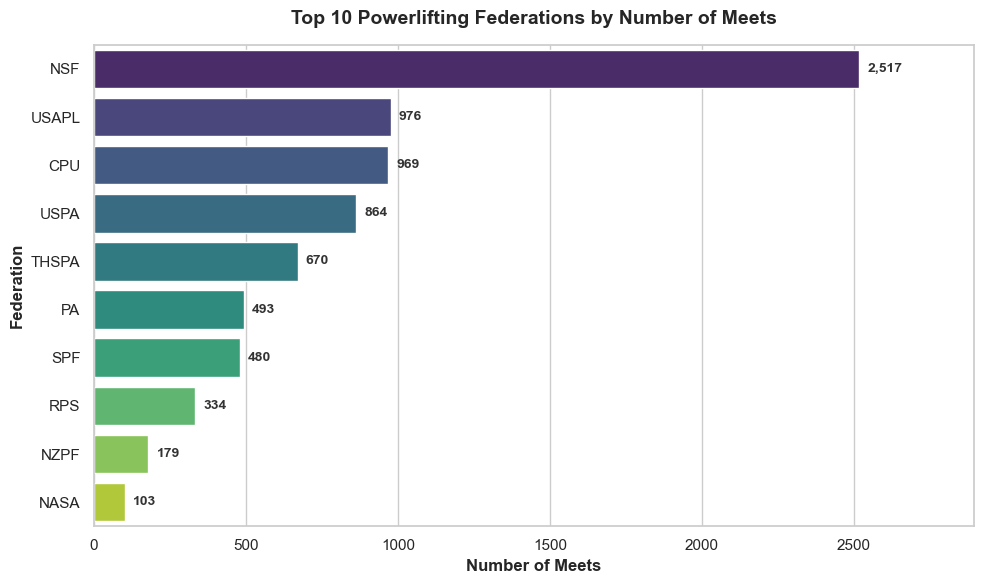

In [32]:
# Prepare top 10 as a DataFrame
top_feds_df = df['Federation'].value_counts().head(10).reset_index()
top_feds_df.columns = ['Federation', 'Count']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Assign hue and set legend=False
ax = sns.barplot(
    data=top_feds_df,
    x='Count',
    y='Federation',
    hue='Federation',
    palette='viridis',
    legend=False
)

# Add data labels
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width):,}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', 
        va='center',
        xytext=(6, 0),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

plt.title('Top 10 Powerlifting Federations by Number of Meets', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Meets', fontsize=12, fontweight='bold')
plt.ylabel('Federation', fontsize=12, fontweight='bold')
plt.xlim(0, top_feds_df['Count'].max() * 1.15)
plt.tight_layout()
plt.show()

In [33]:
df["MeetCountry"].value_counts().head(10)

MeetCountry
USA            3894
Norway         2521
Canada         1066
Australia       532
New Zealand     195
Russia           43
N.Ireland        36
UK               34
Ireland          21
England          16
Name: count, dtype: int64

In [34]:
dftop10countries = df["MeetCountry"].value_counts().head(10).reset_index()
dftop10countries.columns = ["Country", "Count"]
dftop10countries

,Country,Count
0,USA,3894
1,Norway,2521
2,Canada,1066
3,Australia,532
4,New Zealand,195
5,Russia,43
6,N.Ireland,36
7,UK,34
8,Ireland,21
9,England,16


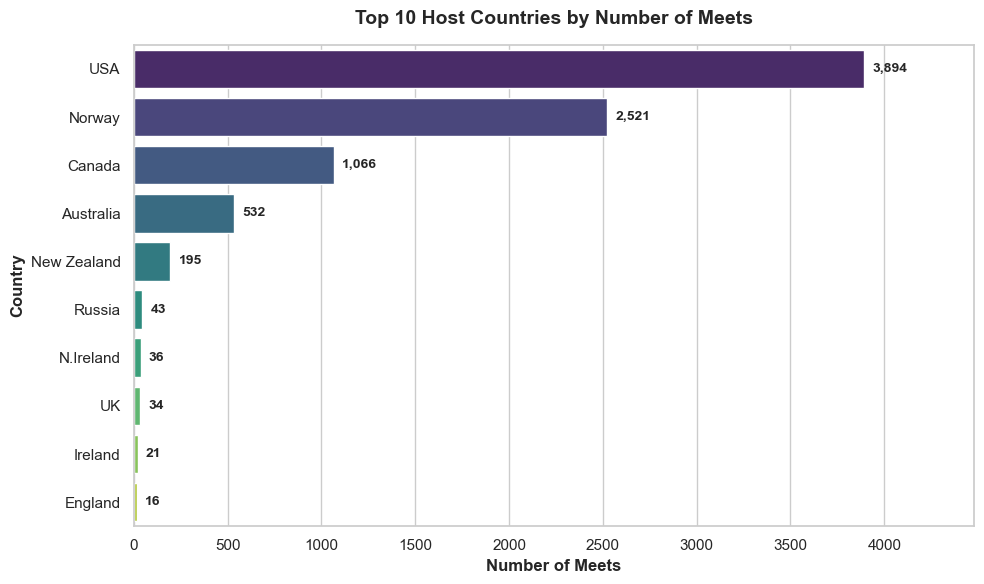

In [35]:
plt.figure(figsize=(10, 6))

# 2. Barplot
ax = sns.barplot(
    data=dftop10countries,
    x='Count',
    y='Country',
    hue='Country',
    palette='viridis'
)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',
            va='center',
            xytext=(6, 0),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )
plt.title('Top 10 Host Countries by Number of Meets', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Meets', fontsize=12, fontweight='bold')
plt.ylabel('Country', fontsize=12, fontweight='bold')
plt.xlim(0, dftop10countries['Count'].max() * 1.15)
plt.tight_layout()
plt.show()

In [36]:
df.head()

,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName,MeetTownClean,MeetStateClean
0,0,365strong/1601,365STRONG,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...,Charlotte,NC
1,1,365strong/1602,365STRONG,2016-11-19,USA,MO,Ozark,Thanksgiving Powerlifting Classic,Ozark,MO
2,2,365strong/1603,365STRONG,2016-07-09,USA,NC,Charlotte,Charlotte Europa Games,Charlotte,NC
3,3,365strong/1604,365STRONG,2016-06-11,USA,SC,Rock Hill,Carolina Cup Push Pull Challenge,Rock Hill,SC
4,4,365strong/1605,365STRONG,2016-04-10,USA,SC,Rock Hill,Eastern USA Challenge,Rock Hill,SC


In [37]:
df['Year'] = df['Date'].dt.year
df

,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName,MeetTownClean,MeetStateClean,Year
0,0,365strong/1601,365STRONG,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...,Charlotte,NC,2016
1,1,365strong/1602,365STRONG,2016-11-19,USA,MO,Ozark,Thanksgiving Powerlifting Classic,Ozark,MO,2016
2,2,365strong/1603,365STRONG,2016-07-09,USA,NC,Charlotte,Charlotte Europa Games,Charlotte,NC,2016
3,3,365strong/1604,365STRONG,2016-06-11,USA,SC,Rock Hill,Carolina Cup Push Pull Challenge,Rock Hill,SC,2016
4,4,365strong/1605,365STRONG,2016-04-10,USA,SC,Rock Hill,Eastern USA Challenge,Rock Hill,SC,2016
...,...,...,...,...,...,...,...,...,...,...,...
8477,8477,xpc/2015-finals,XPC,2015-03-06,USA,OH,Columbus,2015 XPC,Columbus,OH,2015
8478,8478,xpc/2016-bench-freak-show,XPC,2016-03-04,USA,OH,Columbus,2016 XPC Bench Freak Show,Columbus,OH,2016
8479,8479,xpc/2016-elite-finals,XPC,2016-03-04,USA,OH,Columbus,2016 XPC Elite Finals,Columbus,OH,2016
8480,8480,xpc/2016-pro-finals,XPC,2016-03-05,USA,OH,Columbus,2016 XPC PRO Finals,Columbus,OH,2016


In [38]:
df["Year"].value_counts()

Year
2017    1640
2016    1475
2015     865
2014     631
2013     468
2012     385
2011     324
2010     264
2008     234
2007     221
2009     217
2001     200
2000     189
2004     187
2005     172
2006     168
2003     161
2002     138
1991     109
1998      90
1999      74
2018      46
1997      39
1996      28
1982      20
1995      19
1974      18
1990      17
1975      12
1987       9
1983       8
1986       7
1989       7
1985       6
1979       6
1984       5
1993       4
1980       4
1992       3
1994       3
1988       3
1981       2
1978       2
1977       1
1976       1
Name: count, dtype: int64

In [39]:
Meetingperyear = pd.DataFrame(df["Year"].value_counts().reset_index())
Meetingperyear

,Year,count
0,2017,1640
1,2016,1475
2,2015,865
3,2014,631
4,2013,468
5,2012,385
6,2011,324
7,2010,264
8,2008,234
9,2007,221


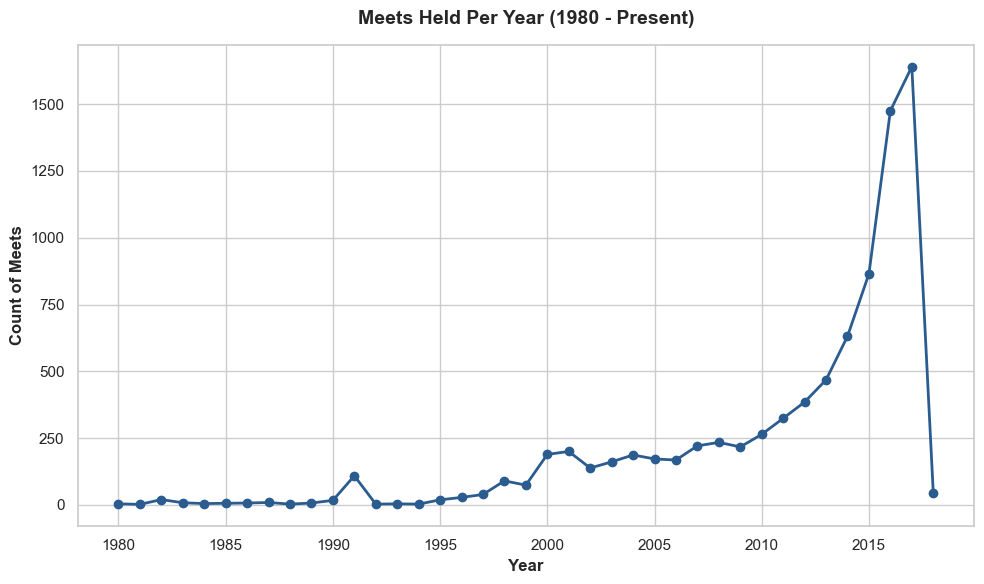

In [40]:
plot_data = Meetingperyear[Meetingperyear['Year'] >= 1980].sort_values('Year')
plt.figure(figsize=(10, 6))
plt.plot(
    plot_data['Year'],
    plot_data['count'],
    marker='o',
    color='#2b5c8f',
    linewidth=2
)
plt.title('Meets Held Per Year (1980 - Present)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Count of Meets', fontsize=12, fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
df.head()

,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName,MeetTownClean,MeetStateClean,Year
0,0,365strong/1601,365STRONG,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...,Charlotte,NC,2016
1,1,365strong/1602,365STRONG,2016-11-19,USA,MO,Ozark,Thanksgiving Powerlifting Classic,Ozark,MO,2016
2,2,365strong/1603,365STRONG,2016-07-09,USA,NC,Charlotte,Charlotte Europa Games,Charlotte,NC,2016
3,3,365strong/1604,365STRONG,2016-06-11,USA,SC,Rock Hill,Carolina Cup Push Pull Challenge,Rock Hill,SC,2016
4,4,365strong/1605,365STRONG,2016-04-10,USA,SC,Rock Hill,Eastern USA Challenge,Rock Hill,SC,2016


In [42]:
Top10USStates= pd.DataFrame(df["MeetState"].value_counts().head(10).reset_index())
Top10USStates

,MeetState,count
0,TX,872
1,CA,399
2,ON,290
3,OH,166
4,PA,164
5,NY,159
6,QC,147
7,AB,145
8,BC,144
9,NSW,144


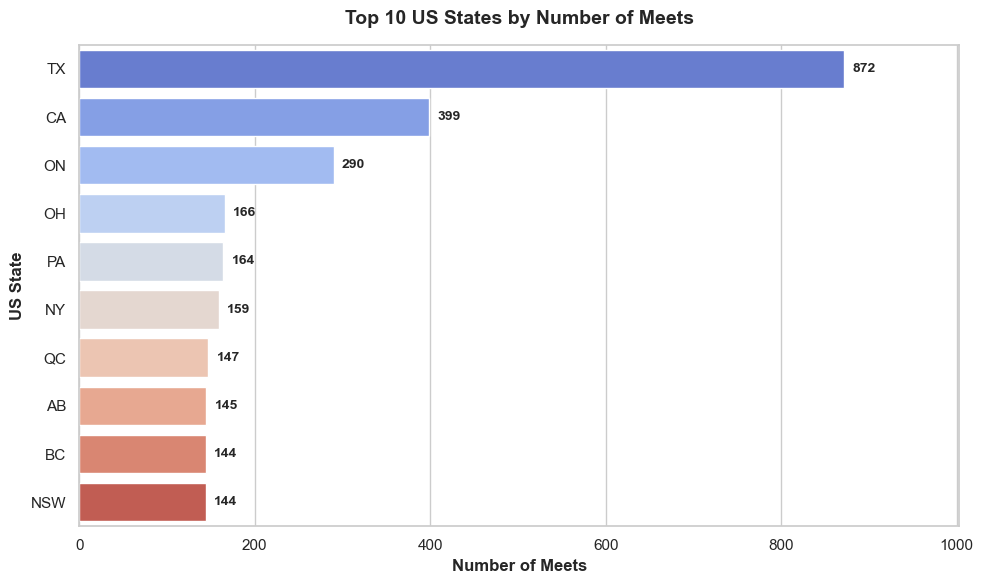

In [43]:
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=Top10USStates,
    x='count',
    y='MeetState',
    palette='coolwarm'
)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',
            va='center',
            xytext=(6, 0),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )
plt.title('Top 10 US States by Number of Meets', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Meets', fontsize=12, fontweight='bold')
plt.ylabel('US State', fontsize=12, fontweight='bold')
plt.xlim(0, Top10USStates['count'].max() * 1.15)
plt.tight_layout()
plt.show()

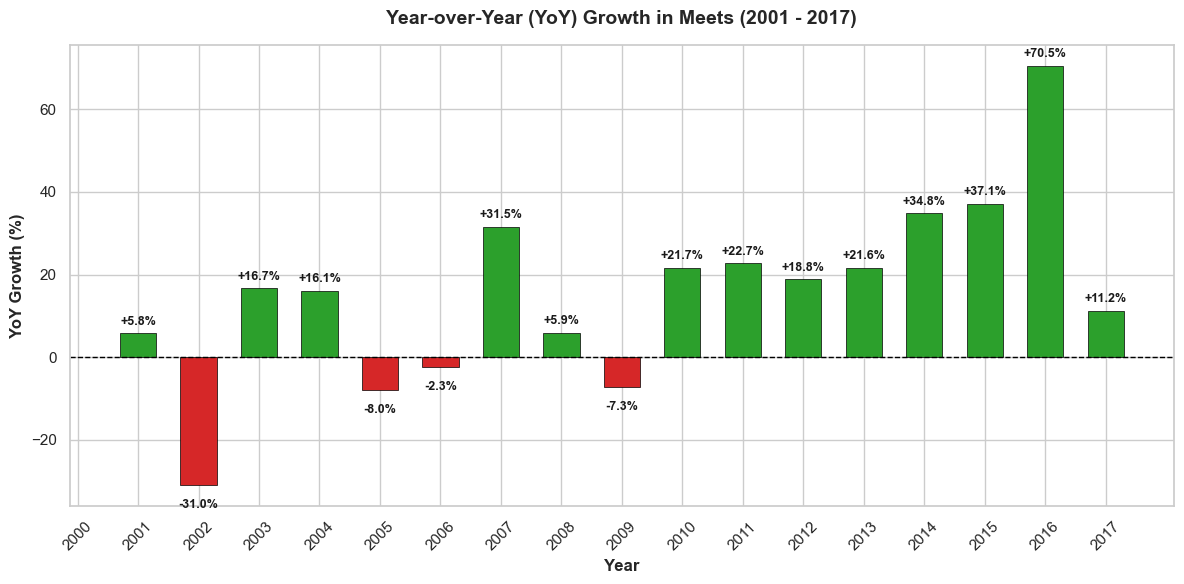

In [44]:
yearly_df = df['Year'].value_counts().sort_index().reset_index()
yearly_df.columns = ['Year', 'Meets_Count']
yoy_df = yearly_df[(yearly_df['Year'] >= 2000) & (yearly_df['Year'] <= 2017)].copy()
yoy_df['YoY_Growth_%'] = (yoy_df['Meets_Count'].pct_change() * 100).round(1)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
bar_colors = ['#2ca02c' if val >= 0 else '#d62728' for val in yoy_df['YoY_Growth_%'].fillna(0)]
bars = plt.bar(
    yoy_df['Year'], 
    yoy_df['YoY_Growth_%'], 
    color=bar_colors, 
    width=0.6,
    edgecolor='black',
    linewidth=0.5
)
for i, row in yoy_df.iterrows():
    val = row['YoY_Growth_%']
    if pd.notna(val):
        va_align = 'bottom' if val >= 0 else 'top'
        y_offset = 4 if val >= 0 else -10
        plt.annotate(
            f"{val:+.1f}%",
            (row['Year'], val),
            xytext=(0, y_offset),
            textcoords='offset points',
            ha='center',
            va=va_align,
            fontsize=9,
            fontweight='bold',
            color='#1a1a1a'
        )
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Year-over-Year (YoY) Growth in Meets (2001 - 2017)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('YoY Growth (%)', fontsize=12, fontweight='bold')
plt.xticks(yoy_df['Year'], rotation=45)
plt.tight_layout()
plt.show()


--- Era: 1980–1999 (Total: 457 meets) ---
MeetCountry
Norway         268
Canada         151
USA             24
New Zealand      5
Indonesia        1
Name: count, dtype: int64

--- Era: 2000–2009 (Total: 1,887 meets) ---
MeetCountry
Norway         1149
Canada          387
USA             212
Australia        85
New Zealand      37
Name: count, dtype: int64

--- Era: 2010–2014 (Total: 2,072 meets) ---
MeetCountry
USA            802
Norway         707
Canada         220
Australia      188
New Zealand     89
Name: count, dtype: int64

--- Era: 2015–2018 (Total: 4,026 meets) ---
MeetCountry
USA            2853
Norway          365
Canada          306
Australia       257
New Zealand      64
Name: count, dtype: int64


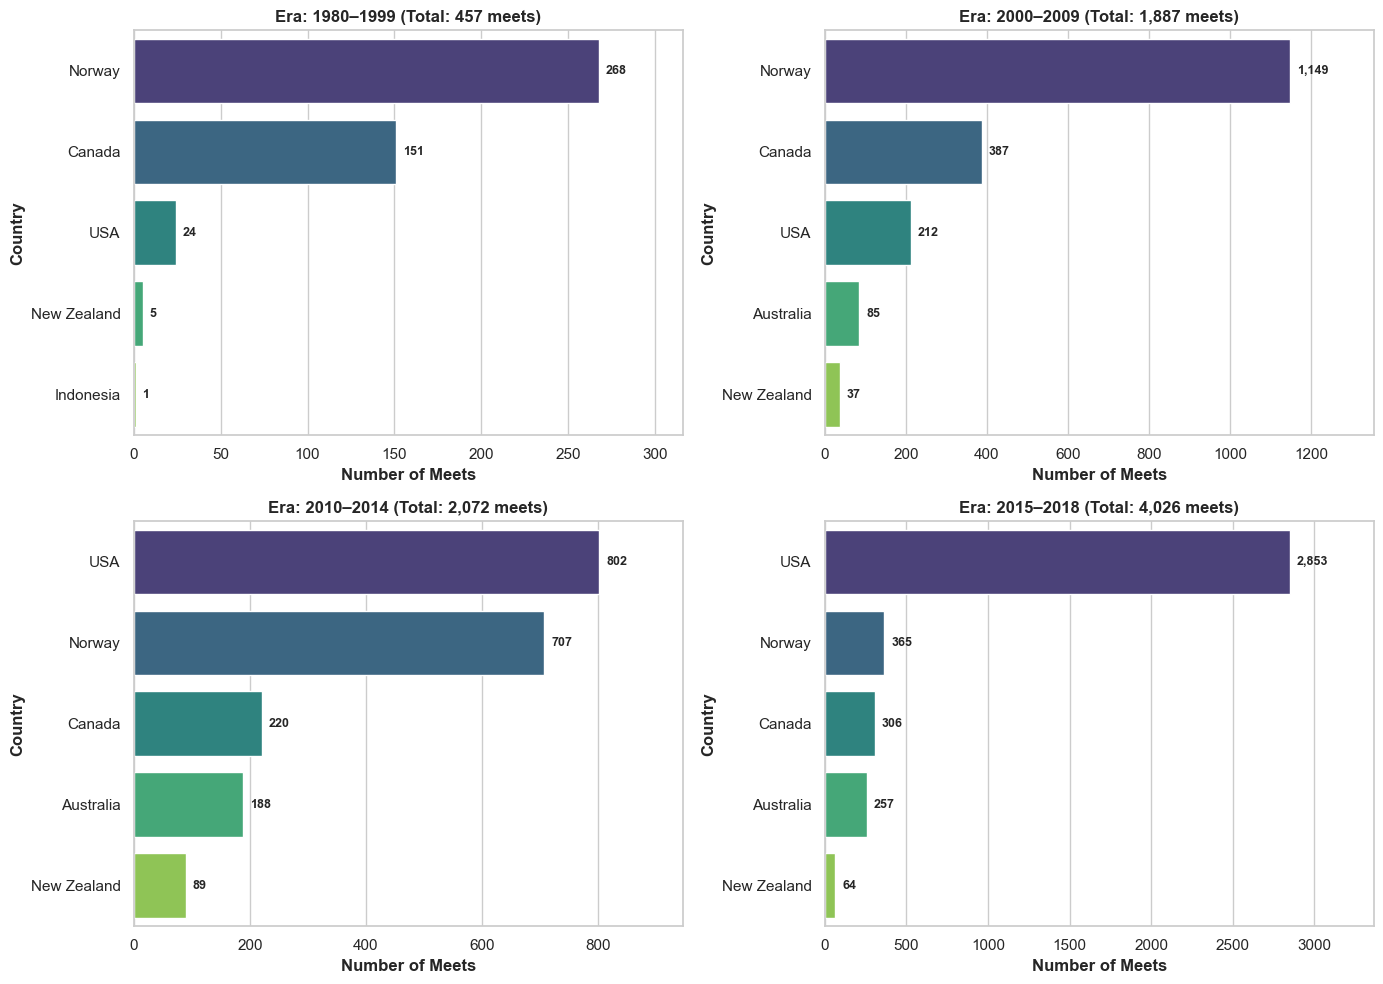

In [45]:
warnings.filterwarnings('ignore', category=FutureWarning)
bins = [1980, 2000, 2010, 2015, 2019]
labels = ['1980–1999', '2000–2009', '2010–2014', '2015–2018']
df['Period'] = pd.cut(df['Year'], bins=bins, labels=labels, right=False)
for period in labels:
    subset = df[df['Period'] == period]
    top_c = subset['MeetCountry'].value_counts().head(5)
    print(f"\n--- Era: {period} (Total: {len(subset):,} meets) ---")
    print(top_c)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, period in enumerate(labels):
    data = df[df['Period'] == period]['MeetCountry'].value_counts().head(5)
    ax = axes[idx]
    
    sns.barplot(x=data.values, y=data.index, ax=ax, palette='viridis')
    ax.set_title(f'Era: {period} (Total: {df[df["Period"] == period].shape[0]:,} meets)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Meets', fontweight='bold')
    ax.set_ylabel('Country', fontweight='bold')
    ax.set_xlim(0, max(data.values) * 1.18)
    

    for p in ax.patches:
        w = p.get_width()
        if w > 0:
            ax.annotate(f'{int(w):,}', (w, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                        fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

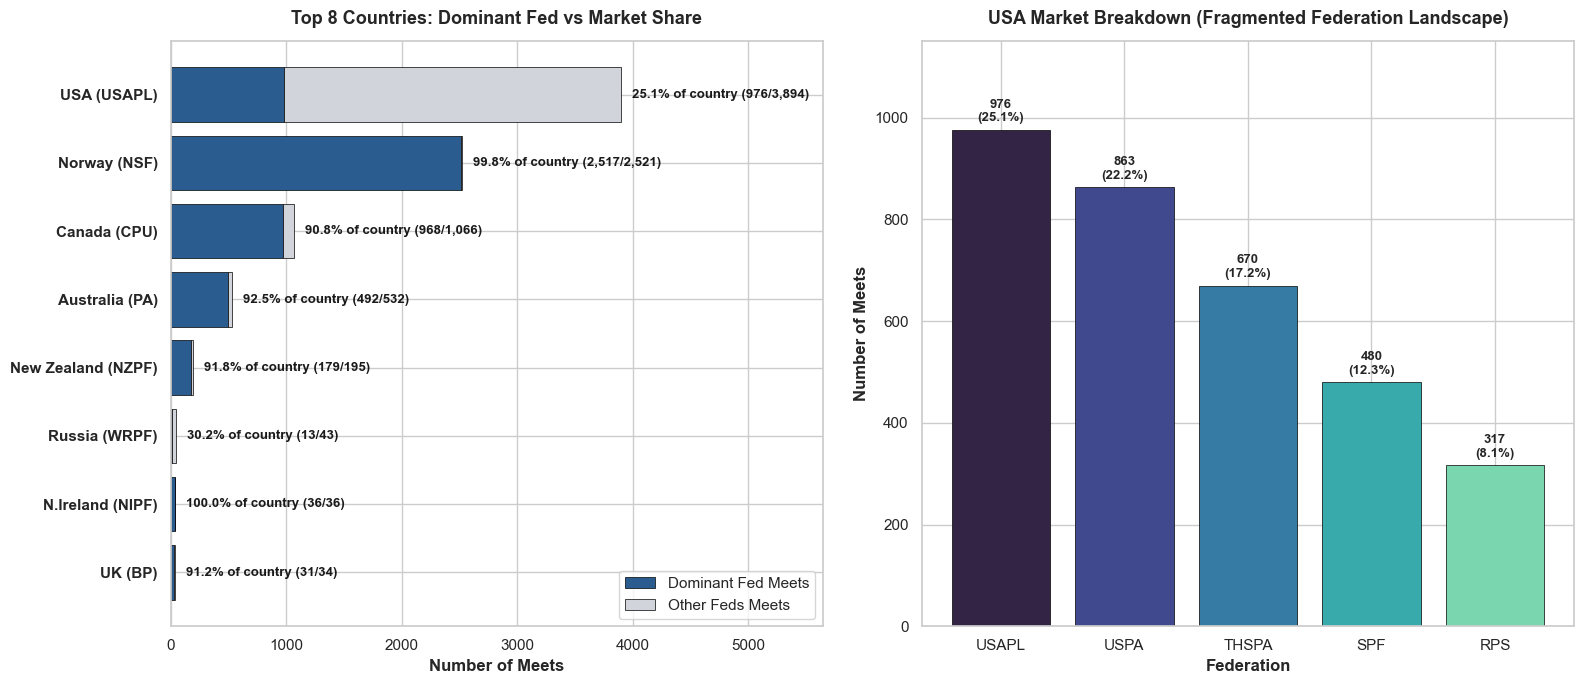

In [46]:
warnings.filterwarnings('ignore', category=FutureWarning)
country_totals = df.groupby('MeetCountry').size().reset_index(name='TotalCountryMeets')
country_fed_counts = df.groupby(['MeetCountry', 'Federation']).size().reset_index(name='MeetCount')
dominant_feds = (
    country_fed_counts
    .sort_values(by=['MeetCountry', 'MeetCount'], ascending=[True, False])
    .drop_duplicates(subset=['MeetCountry'])
    .reset_index(drop=True)
)
dominant_feds = pd.merge(dominant_feds, country_totals, on='MeetCountry')
dominant_feds['Share_%'] = ((dominant_feds['MeetCount'] / dominant_feds['TotalCountryMeets']) * 100).round(1)
dominant_feds['OtherMeets'] = dominant_feds['TotalCountryMeets'] - dominant_feds['MeetCount']
top8_dom = dominant_feds.sort_values(by='TotalCountryMeets', ascending=False).head(8)
usa_feds = df[df['MeetCountry'] == 'USA']['Federation'].value_counts().head(5)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")
y_pos = range(len(top8_dom))
labels = [f"{row['MeetCountry']} ({row['Federation']})" for _, row in top8_dom.iterrows()]

axes[0].barh(y_pos, top8_dom['MeetCount'], color='#2b5c8f', label='Dominant Fed Meets', edgecolor='black', linewidth=0.5)
axes[0].barh(y_pos, top8_dom['OtherMeets'], left=top8_dom['MeetCount'], color='#d1d5db', label='Other Feds Meets', edgecolor='black', linewidth=0.5)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(labels, fontsize=11, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of Meets', fontsize=12, fontweight='bold')
axes[0].set_title('Top 8 Countries: Dominant Fed vs Market Share', fontsize=13, fontweight='bold', pad=12)
axes[0].legend(loc='lower right', frameon=True)

# Add annotations to Panel 1
for i, row in top8_dom.reset_index(drop=True).iterrows():
    total = row['TotalCountryMeets']
    share = row['Share_%']
    axes[0].annotate(f"{share}% of country ({row['MeetCount']:,}/{total:,})",
                    (total, i),
                    xytext=(8, 0),
                    textcoords='offset points',
                    va='center',
                    fontsize=9.5,
                    fontweight='bold',
                    color='#1a1a1a')
axes[0].set_xlim(0, max(top8_dom['TotalCountryMeets']) * 1.45)
colors_usa = sns.color_palette('mako', len(usa_feds))
bars_usa = axes[1].bar(usa_feds.index, usa_feds.values, color=colors_usa, edgecolor='black', linewidth=0.5)
axes[1].set_title('USA Market Breakdown (Fragmented Federation Landscape)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Federation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Meets', fontsize=12, fontweight='bold')
for p in bars_usa:
    h = p.get_height()
    pct = (h / 3894) * 100
    axes[1].annotate(f"{h:,}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='bottom',
                     xytext=(0, 4),
                     textcoords='offset points',
                     fontsize=9.5,
                     fontweight='bold')
axes[1].set_ylim(0, max(usa_feds.values) * 1.18)
plt.tight_layout()
plt.show()